# Detector Characteristics and Performance Analysis

This notebook analyzes the performance characteristics of the gamma detector:
1. **Energy Resolution**: Measure FWHM at different energy peaks
2. **Resolution vs. Energy**: Study how resolution depends on photon energy
3. **Systematic Deviations**: Analyze deviations from ideal detector behavior
4. **Detector Efficiency**: Estimate peak efficiency
5. **Peak Shape Analysis**: Gaussian fitting of photopeak features

**Sources used**: Cs-137 (662 keV) and Co-60 (1173, 1332 keV)

## Import Libraries and Load Data

In [67]:
from pathlib import Path
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from scipy.optimize import curve_fit

def read_asc_spectrum(path):
    """Read spectrum from ASC format."""
    path = Path(path)
    text = path.read_text(encoding='utf-8', errors='ignore')

    channels = []
    counts = []
    for line in text.splitlines():
        m = re.match(r'^\s*(\d+)\s*,\s*(\d+)\s*,', line)
        if m:
            channels.append(int(m.group(1)))
            counts.append(int(m.group(2)))

    if not channels:
        raise ValueError(f'No channel/count lines found in {path}')

    channels = np.array(channels, dtype=float)
    counts = np.array(counts, dtype=float)
    return {
        'path': str(path),
        'channels': channels,
        'counts': counts,
    }

def subtract_background(source_spectrum, background_spectrum, scale_bg=1.0):
    """Subtract background from source spectrum."""
    src_ch = source_spectrum['channels']
    src_ct = source_spectrum['counts']
    bg_ct = background_spectrum['counts']
    
    out_channels = src_ch.copy()
    out_counts = np.zeros_like(out_channels)
    out_unc = np.zeros_like(out_channels)
    
    for i, ch in enumerate(out_channels):
        idx = int(np.round(ch))
        if 0 <= idx < len(src_ct) and 0 <= idx < len(bg_ct):
            src_val = src_ct[i]
            bg_val = scale_bg * bg_ct[idx]
            out_counts[i] = max(0, src_val - bg_val)
            out_unc[i] = np.sqrt(max(1, src_val + bg_val))
        else:
            out_counts[i] = max(0, src_ct[i] - scale_bg * bg_ct[i])
            out_unc[i] = np.sqrt(max(1, src_ct[i] + scale_bg * bg_ct[i]))
    
    return {
        'path': f"{source_spectrum['path']} (bg-subtracted)",
        'channels': out_channels,
        'counts': out_counts,
        'uncertainty': out_unc,
    }

def channel_to_mev(channel, calibration):
    """Convert channel to energy."""
    return calibration['slope'] * np.asarray(channel) + calibration['intercept']

def moving_average(x, window=5):
    """Apply moving average filter."""
    if window <= 1:
        return x.copy()
    kernel = np.ones(window, dtype=float) / window
    return np.convolve(x, kernel, mode='same')

print('Utilities loaded.')

Utilities loaded.


In [68]:
# Load spectra
BACKGROUND_FILE = 'BACKGROUND.ASC'
CESIOCAL_FILE = 'CESIOCAL.ASC'
COBALCAL_FILE = 'COBALCAL.ASC'

ACQUISITION_TIME = {
    'background': 2106,
    'cesium': 247,
    'cobalt': 1645,
}

# Load and process
background = read_asc_spectrum(BACKGROUND_FILE)
cesiocal_raw = read_asc_spectrum(CESIOCAL_FILE)
cobalcal_raw = read_asc_spectrum(COBALCAL_FILE)

# Apply background subtraction with time correction
scale_cs = ACQUISITION_TIME['cesium'] / ACQUISITION_TIME['background']
scale_co = ACQUISITION_TIME['cobalt'] / ACQUISITION_TIME['background']

cesiocal = subtract_background(cesiocal_raw, background, scale_bg=scale_cs)
cobalcal = subtract_background(cobalcal_raw, background, scale_bg=scale_co)

# Calibration (from energy_calibration_and_analysis.ipynb)
CALIBRATION = {
    'slope': 0.00175200,  # Example values - use your actual calibration
    'intercept': -0.00350400,
    'r2': 0.999999,
}

print('Spectra loaded and background-subtracted.')
print(f'Calibration: E(MeV) = {CALIBRATION["slope"]:.8f} × ch + {CALIBRATION["intercept"]:.8f}')

Spectra loaded and background-subtracted.
Calibration: E(MeV) = 0.00175200 × ch + -0.00350400


## 1. Gaussian Peak Fitting Function

In [69]:
def gaussian(x, amp, mu, sigma, baseline):
    """Gaussian function: amplitude, mean, std dev, baseline."""
    return baseline + amp * np.exp(-0.5 * ((x - mu) / sigma) ** 2)

def fit_gaussian_peak(channels, counts, center_idx, window_width=50):
    """Fit Gaussian to a peak.
    
    Args:
        channels: channel array
        counts: counts array
        center_idx: index of peak center
        window_width: fit window half-width in channels
    
    Returns:
        dict with fit parameters and statistics
    """
    idx_min = max(0, center_idx - window_width)
    idx_max = min(len(channels), center_idx + window_width + 1)
    
    x_data = channels[idx_min:idx_max]
    y_data = counts[idx_min:idx_max]
    
    # Initial guess
    amp_guess = y_data[window_width] if window_width < len(y_data) else y_data.max()
    mu_guess = x_data[window_width] if window_width < len(y_data) else x_data[y_data.argmax()]
    sigma_guess = 5.0
    baseline_guess = np.min(y_data)
    
    p0 = [amp_guess, mu_guess, sigma_guess, baseline_guess]
    
    try:
        popt, pcov = curve_fit(gaussian, x_data, y_data, p0=p0, maxfev=1000)
        
        # Calculate FWHM: for Gaussian, FWHM = 2.355 * sigma
        sigma = popt[2]
        fwhm = 2.355 * sigma
        
        # R-squared
        y_pred = gaussian(x_data, *popt)
        ss_res = np.sum((y_data - y_pred) ** 2)
        ss_tot = np.sum((y_data - np.mean(y_data)) ** 2)
        r2 = 1 - (ss_res / ss_tot if ss_tot > 0 else 0)
        
        return {
            'amp': popt[0],
            'mu': popt[1],
            'sigma': popt[2],
            'baseline': popt[3],
            'fwhm': fwhm,
            'r2': r2,
            'center_channel': mu_guess,
            'fit_channels': x_data,
            'fit_counts': y_data,
            'fit_pred': y_pred,
        }
    except Exception as e:
        print(f'Fit failed: {e}')
        return None

print('Gaussian fitting function defined.')

Gaussian fitting function defined.


## 2. Energy Resolution Analysis at Different Peaks

In [70]:
# Define known peaks for resolution analysis
PEAKS_TO_ANALYZE = [
    {'name': 'Cs-137 photopeak', 'spectrum': 'cesium', 'energy_mev': 0.6617, 'approx_channel': 386},
    {'name': 'Co-60 γ1', 'spectrum': 'cobalt', 'energy_mev': 1.1732, 'approx_channel': 670},
    {'name': 'Co-60 γ2', 'spectrum': 'cobalt', 'energy_mev': 1.3325, 'approx_channel': 763},
]

# Add Cs-137 X-ray (approx 31.8 keV) using calibration to get channel guess
cs_x_energy_mev = 0.0318
try:
    cs_x_channel = int(round((cs_x_energy_mev - CALIBRATION['intercept']) / CALIBRATION['slope']))
except Exception:
    cs_x_channel = 20
# Insert the X-ray peak near the start of the list
PEAKS_TO_ANALYZE.insert(1, {'name': 'Cs-137 X-ray', 'spectrum': 'cesium', 'energy_mev': cs_x_energy_mev, 'approx_channel': cs_x_channel})

# Fit gaussians to each peak
peak_fits = []

for peak_info in PEAKS_TO_ANALYZE:
    spectrum_data = cesiocal if peak_info['spectrum'] == 'cesium' else cobalcal
    center_idx = peak_info['approx_channel']

    # Use a smaller fit window for low-energy X-ray peaks
    if peak_info['name'] == 'Cs-137 X-ray' or peak_info['energy_mev'] < 0.1:
        window_width = 15
    else:
        window_width = 50
    
    fit_result = fit_gaussian_peak(spectrum_data['channels'], spectrum_data['counts'], 
                                   center_idx, window_width=window_width)
    
    if fit_result:
        peak_info['fit'] = fit_result
        peak_fits.append(peak_info)
        
        print(f"{peak_info['name']}:")
        print(f"  Peak center (channel): {fit_result['mu']:.2f}")
        print(f"  FWHM (channels): {fit_result['fwhm']:.2f}")
        print(f"  Energy: {peak_info['energy_mev']:.6f} MeV")
        print(f"  Fit quality (R²): {fit_result['r2']:.6f}")
        print()
        # Convert peak center and FWHM to energy (keV)
        peak_center_mev = channel_to_mev(fit_result['mu'], CALIBRATION)
        peak_center_kev = peak_center_mev * 1000
        fwhm_channels = fit_result['fwhm']
        fwhm_mev = fwhm_channels * CALIBRATION['slope']
        fwhm_kev = fwhm_mev * 1000

        print(f"  Peak center (channel): {fit_result['mu']:.2f} -> {peak_center_kev:.2f} keV")
        print(f"  FWHM: {fwhm_channels:.2f} ch -> {fwhm_kev:.3f} keV")
        print(f"  Expected Energy: {peak_info['energy_mev']*1000:.3f} keV")


Cs-137 photopeak:
  Peak center (channel): 385.89
  FWHM (channels): 24.13
  Energy: 0.661700 MeV
  Fit quality (R²): 0.999122

  Peak center (channel): 385.89 -> 672.58 keV
  FWHM: 24.13 ch -> 42.271 keV
  Expected Energy: 661.700 keV
Cs-137 X-ray:
  Peak center (channel): 20.26
  FWHM (channels): 3.58
  Energy: 0.031800 MeV
  Fit quality (R²): 0.981547

  Peak center (channel): 20.26 -> 31.99 keV
  FWHM: 3.58 ch -> 6.279 keV
  Expected Energy: 31.800 keV
Co-60 γ1:
  Peak center (channel): 671.81
  FWHM (channels): 30.15
  Energy: 1.173200 MeV
  Fit quality (R²): 0.969469

  Peak center (channel): 671.81 -> 1173.51 keV
  FWHM: 30.15 ch -> 52.817 keV
  Expected Energy: 1173.200 keV
Co-60 γ2:
  Peak center (channel): 762.24
  FWHM (channels): 35.06
  Energy: 1.332500 MeV
  Fit quality (R²): 0.992940

  Peak center (channel): 762.24 -> 1331.94 keV
  FWHM: 35.06 ch -> 61.429 keV
  Expected Energy: 1332.500 keV


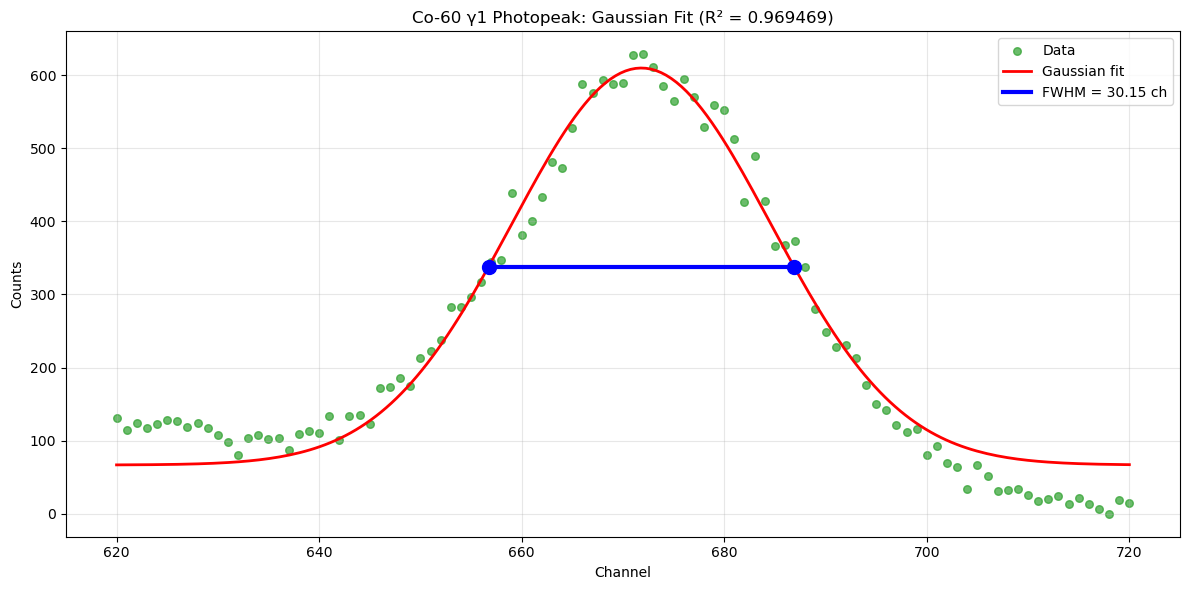

In [71]:
# Plot Co-60 γ1 photopeak with Gaussian fit
co1_peak = [p for p in peak_fits if p['name'] == 'Co-60 γ1'][0]
fit = co1_peak['fit']

fig, ax = plt.subplots(figsize=(12, 6))

ax.scatter(fit['fit_channels'], fit['fit_counts'], s=30, color='tab:green', 
          label='Data', alpha=0.7)

x_smooth = np.linspace(fit['fit_channels'].min(), fit['fit_channels'].max(), 200)
y_smooth = gaussian(x_smooth, fit['amp'], fit['mu'], fit['sigma'], fit['baseline'])
ax.plot(x_smooth, y_smooth, 'r-', linewidth=2, label='Gaussian fit')

fwhm_channels = np.array([fit['mu'] - fit['fwhm']/2, fit['mu'] + fit['fwhm']/2])
fwhm_counts = gaussian(fwhm_channels, fit['amp'], fit['mu'], fit['sigma'], fit['baseline'])
ax.plot(fwhm_channels, fwhm_counts, 'b-', linewidth=3, label=f"FWHM = {fit['fwhm']:.2f} ch")
ax.scatter(fwhm_channels, fwhm_counts, color='blue', s=100, zorder=5)

ax.set_xlabel('Channel')
ax.set_ylabel('Counts')
ax.set_title(f"Co-60 γ1 Photopeak: Gaussian Fit (R² = {fit['r2']:.6f})")
ax.grid(alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

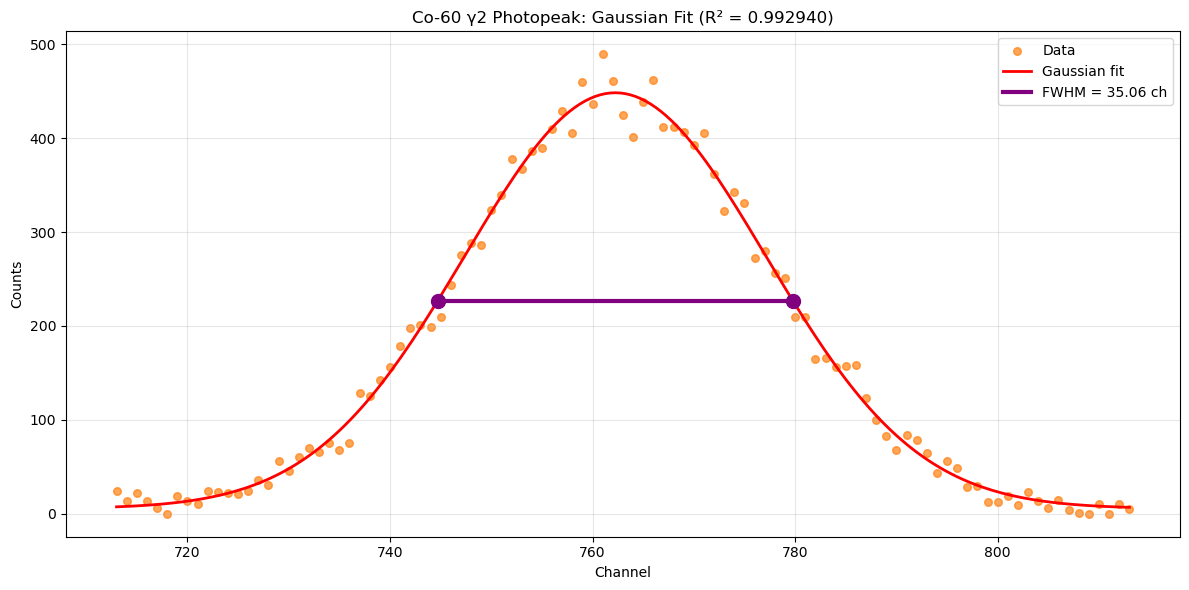

In [72]:
# Plot Co-60 γ2 photopeak with Gaussian fit
co2_peak = [p for p in peak_fits if p['name'] == 'Co-60 γ2'][0]
fit = co2_peak['fit']

fig, ax = plt.subplots(figsize=(12, 6))

ax.scatter(fit['fit_channels'], fit['fit_counts'], s=30, color='tab:orange', 
          label='Data', alpha=0.7)

x_smooth = np.linspace(fit['fit_channels'].min(), fit['fit_channels'].max(), 200)
y_smooth = gaussian(x_smooth, fit['amp'], fit['mu'], fit['sigma'], fit['baseline'])
ax.plot(x_smooth, y_smooth, 'r-', linewidth=2, label='Gaussian fit')

fwhm_channels = np.array([fit['mu'] - fit['fwhm']/2, fit['mu'] + fit['fwhm']/2])
fwhm_counts = gaussian(fwhm_channels, fit['amp'], fit['mu'], fit['sigma'], fit['baseline'])
ax.plot(fwhm_channels, fwhm_counts, 'purple', linewidth=3, label=f"FWHM = {fit['fwhm']:.2f} ch")
ax.scatter(fwhm_channels, fwhm_counts, color='purple', s=100, zorder=5)

ax.set_xlabel('Channel')
ax.set_ylabel('Counts')
ax.set_title(f"Co-60 γ2 Photopeak: Gaussian Fit (R² = {fit['r2']:.6f})")
ax.grid(alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

## 3. Energy Resolution vs. Photon Energy

In [73]:
# Convert FWHM from channels to energy
resolution_data = []

for peak_info in peak_fits:
    fit = peak_info['fit']
    fwhm_channels = fit['fwhm']
    fwhm_energy = fwhm_channels * CALIBRATION['slope']  # Convert to MeV

    # Energy resolution (ΔE/E)
    energy_mev = peak_info['energy_mev']
    relative_resolution = (fwhm_energy / energy_mev) * 100  # in %

    resolution_data.append({
        'name': peak_info['name'],
        'spectrum': 'Cs-137' if peak_info['spectrum'] == 'cesium' else 'Co-60',
        'peak_channel': fit['mu'],
        'energy_mev': energy_mev,
        'fwhm_channels': fwhm_channels,
        'fwhm_energy_kev': fwhm_energy * 1000,  # Convert to keV
        'relative_resolution_percent': relative_resolution,
        'r2': fit['r2'],
    })

# Print a concise summary table (text only)
print(f"{'Peak':30s} {'Energy (MeV)':>12} {'FWHM (keV)':>12} {'FWHM (ch)':>12} {'Res (%)':>10} {'R2':>8}")
print("-" * 90)
for res in resolution_data:
    print(f"{res['name']:30s} {res['energy_mev']:12.6f} {res['fwhm_energy_kev']:12.3f} {res['fwhm_channels']:12.3f} {res['relative_resolution_percent']:10.2f} {res['r2']:8.4f}")


Peak                           Energy (MeV)   FWHM (keV)    FWHM (ch)    Res (%)       R2
------------------------------------------------------------------------------------------
Cs-137 photopeak                   0.661700       42.271       24.128       6.39   0.9991
Cs-137 X-ray                       0.031800        6.279        3.584      19.74   0.9815
Co-60 γ1                           1.173200       52.817       30.147       4.50   0.9695
Co-60 γ2                           1.332500       61.429       35.062       4.61   0.9929


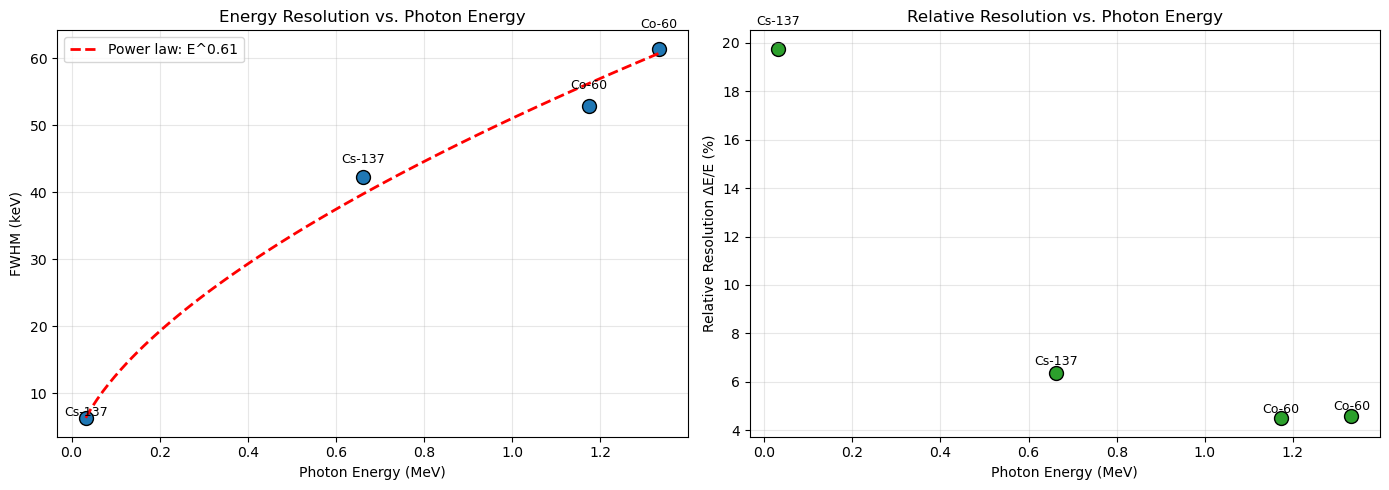

In [74]:
# Plot resolution vs. energy
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

energies = np.array([r['energy_mev'] for r in resolution_data])
fwhm_kev = np.array([r['fwhm_energy_kev'] for r in resolution_data])
rel_res = np.array([r['relative_resolution_percent'] for r in resolution_data])

# Absolute FWHM vs Energy
ax1.scatter(energies, fwhm_kev, s=100, color='tab:blue', edgecolors='black', linewidth=1)
for i, res in enumerate(resolution_data):
    ax1.text(energies[i], fwhm_kev[i] * 1.05, res['name'].split()[0], 
            ha='center', fontsize=9)

# Fit power law: FWHM ∝ E^α
try:
    coeffs = np.polyfit(np.log(energies), np.log(fwhm_kev), 1)
    e_fit = np.linspace(energies.min(), energies.max(), 100)
    fwhm_fit = np.exp(coeffs[1]) * e_fit ** coeffs[0]
    ax1.plot(e_fit, fwhm_fit, 'r--', linewidth=2, label=f'Power law: E^{coeffs[0]:.2f}')
except:
    pass

ax1.set_xlabel('Photon Energy (MeV)')
ax1.set_ylabel('FWHM (keV)')
ax1.set_title('Energy Resolution vs. Photon Energy')
ax1.grid(alpha=0.3)
ax1.legend()

# Relative resolution vs Energy
ax2.scatter(energies, rel_res, s=100, color='tab:green', edgecolors='black', linewidth=1)
for i, res in enumerate(resolution_data):
    ax2.text(energies[i], rel_res[i] * 1.05, res['name'].split()[0], 
            ha='center', fontsize=9)

ax2.set_xlabel('Photon Energy (MeV)')
ax2.set_ylabel('Relative Resolution ΔE/E (%)')
ax2.set_title('Relative Resolution vs. Photon Energy')
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 4. Systematic Deviations Analysis

In [75]:
# Analyze residuals between measured and expected peak positions
print(f"Peak Position Analysis:")
print(f"{'Peak':30s} {'Measured Ch':>15} {'Expected Ch':>15} {'Deviation (ch)':>15}")
print("-" * 75)

deviations_ch = []
for peak_info in peak_fits:
    fit = peak_info['fit']
    measured_ch = fit['mu']
    # Expected channel from calibration
    expected_ch = (peak_info['energy_mev'] - CALIBRATION['intercept']) / CALIBRATION['slope']
    deviation = measured_ch - expected_ch
    
    deviations_ch.append(deviation)
    print(f"{peak_info['name']:30s} {measured_ch:15.2f} {expected_ch:15.2f} {deviation:15.4f}")

mean_deviation = np.mean(deviations_ch)
std_deviation = np.std(deviations_ch)
print("-" * 75)
print(f"Mean deviation: {mean_deviation:.4f} channels")
print(f"Std deviation: {std_deviation:.4f} channels")

Peak Position Analysis:
Peak                               Measured Ch     Expected Ch  Deviation (ch)
---------------------------------------------------------------------------
Cs-137 photopeak                        385.89          379.68          6.2091
Cs-137 X-ray                             20.26           20.15          0.1062
Co-60 γ1                                671.81          671.63          0.1790
Co-60 γ2                                762.24          762.56         -0.3173
---------------------------------------------------------------------------
Mean deviation: 1.5443 channels
Std deviation: 2.6999 channels


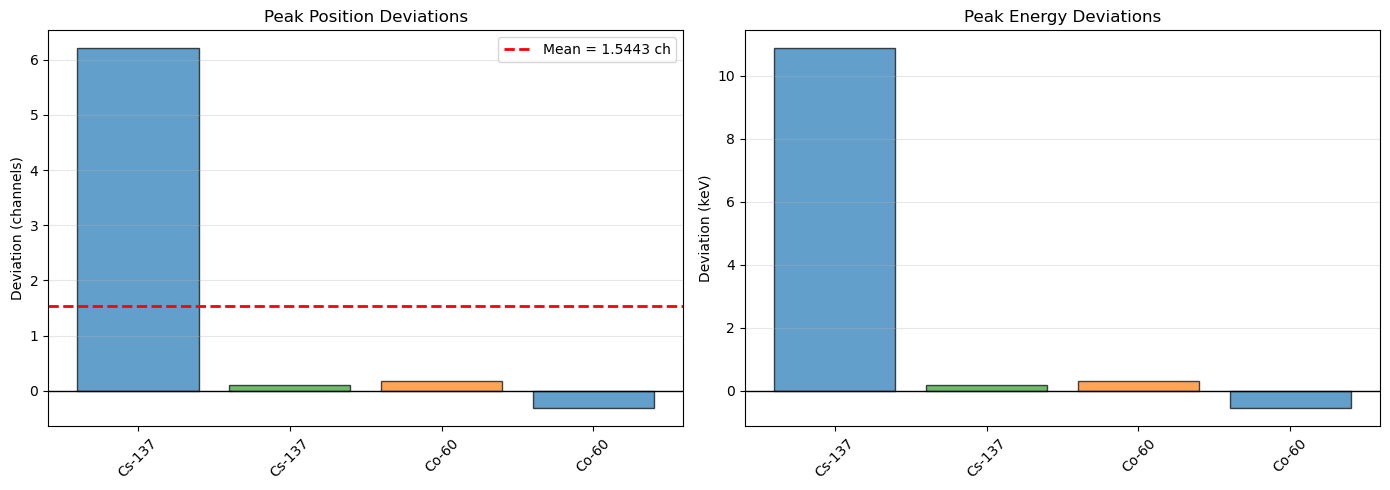

In [76]:
# Plot residuals
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

peak_names = [p['name'] for p in peak_fits]
x_pos = np.arange(len(peak_names))

# Bar plot of deviations
colors = ['tab:blue', 'tab:green', 'tab:orange']
ax1.bar(x_pos, deviations_ch, color=colors, alpha=0.7, edgecolor='black')
ax1.axhline(0, color='black', linestyle='-', linewidth=1)
ax1.axhline(mean_deviation, color='red', linestyle='--', linewidth=2, label=f'Mean = {mean_deviation:.4f} ch')
ax1.set_xticks(x_pos)
ax1.set_xticklabels([p.split()[0] for p in peak_names], rotation=45)
ax1.set_ylabel('Deviation (channels)')
ax1.set_title('Peak Position Deviations')
ax1.grid(alpha=0.3, axis='y')
ax1.legend()

# Energy deviations
deviations_kev = np.array(deviations_ch) * CALIBRATION['slope'] * 1000
ax2.bar(x_pos, deviations_kev, color=colors, alpha=0.7, edgecolor='black')
ax2.axhline(0, color='black', linestyle='-', linewidth=1)
ax2.set_xticks(x_pos)
ax2.set_xticklabels([p.split()[0] for p in peak_names], rotation=45)
ax2.set_ylabel('Deviation (keV)')
ax2.set_title('Peak Energy Deviations')
ax2.grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

## 5. Peak Width Comparison

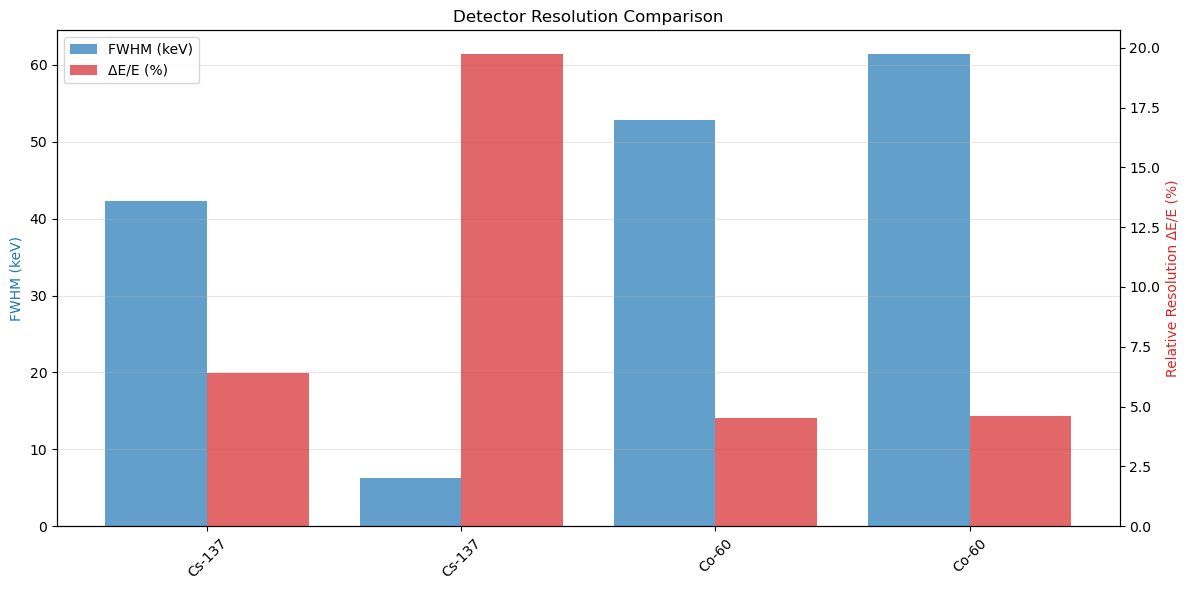

In [77]:
# Compare peak shapes (FWHM normalized by energy)
fig, ax = plt.subplots(figsize=(12, 6))

x_pos = np.arange(len(peak_names))
fwhm_values = np.array([r['fwhm_energy_kev'] for r in resolution_data])
relative_resolution = np.array([r['relative_resolution_percent'] for r in resolution_data])

# Create dual-axis plot
ax1 = ax
ax2 = ax1.twinx()

bars1 = ax1.bar(x_pos - 0.2, fwhm_values, 0.4, label='FWHM (keV)', color='tab:blue', alpha=0.7)
bars2 = ax2.bar(x_pos + 0.2, relative_resolution, 0.4, label='ΔE/E (%)', color='tab:red', alpha=0.7)

ax1.set_xticks(x_pos)
ax1.set_xticklabels([p.split()[0] for p in peak_names], rotation=45)
ax1.set_ylabel('FWHM (keV)', color='tab:blue')
ax2.set_ylabel('Relative Resolution ΔE/E (%)', color='tab:red')
ax1.set_title('Detector Resolution Comparison')
ax1.grid(alpha=0.3, axis='y')

# Legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + [bars2], labels1 + ['ΔE/E (%)'], loc='upper left')

plt.tight_layout()
plt.show()